In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\jabee\OneDrive\Desktop\projects\student_score_prediction\data\student_scores.csv")

In [3]:
df.head()

,Hours,Marks
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [4]:
df.info

<bound method DataFrame.info of     Hours  Marks
0     2.5     21
1     5.1     47
2     3.2     27
3     8.5     75
4     3.5     30
5     1.5     20
6     9.2     88
7     5.5     60
8     8.3     81
9     2.7     25
10    7.7     85
11    5.9     62
12    4.5     41
13    3.3     42
14    1.1     17
15    8.9     95
16    2.5     30
17    1.9     24
18    6.1     67
19    7.4     69
20    2.7     30
21    4.8     54
22    3.8     35
23    6.9     76
24    7.8     86>

In [5]:
df.shape

(25, 2)

In [6]:
df.describe()

,Hours,Marks
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [7]:
df.dtypes

Hours    float64
Marks      int64
dtype: object

In [8]:
df.columns

Index(['Hours', 'Marks'], dtype='object')

In [9]:
df.isnull().sum()

Hours    0
Marks    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.head()

,Hours,Marks
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


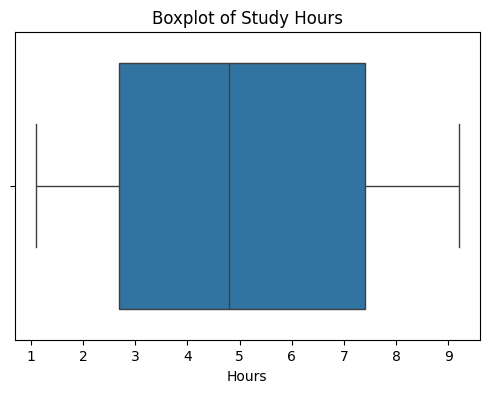

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Hours'])
plt.title("Boxplot of Study Hours")
plt.show()

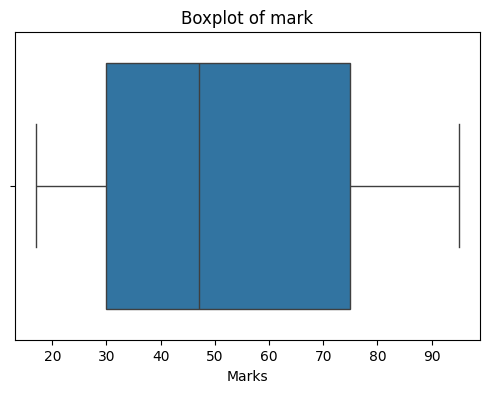

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Marks'])
plt.title("Boxplot of mark")
plt.show()

# EDA

In [14]:
df.columns

Index(['Hours', 'Marks'], dtype='object')

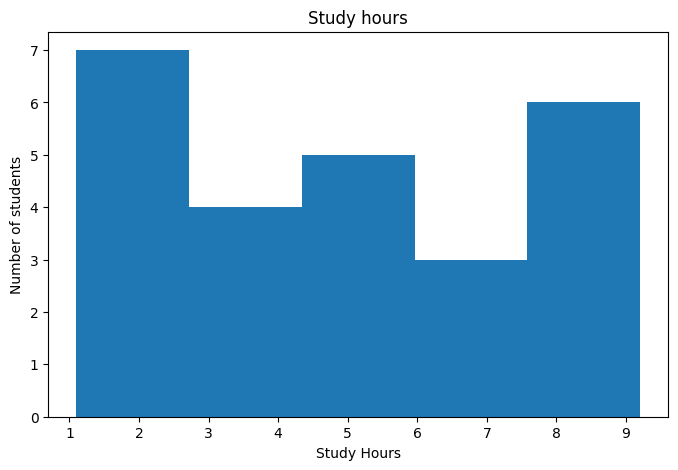

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Hours'],
    bins=5
)

plt.title("Distribution Study hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of students")

plt.show()

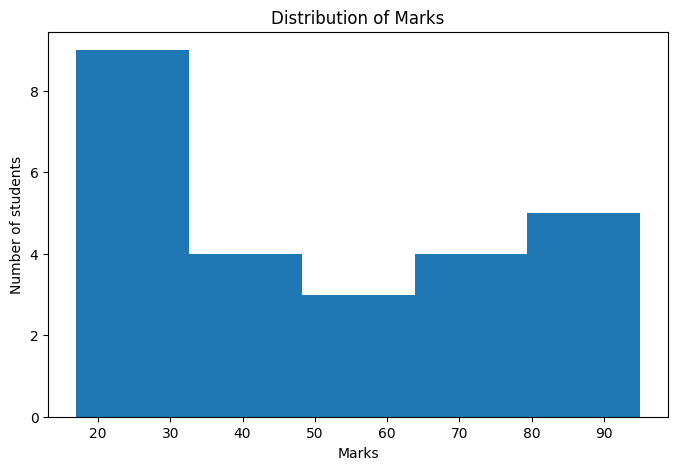

In [19]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Marks'],
    bins=5
)

plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of students")

plt.show()

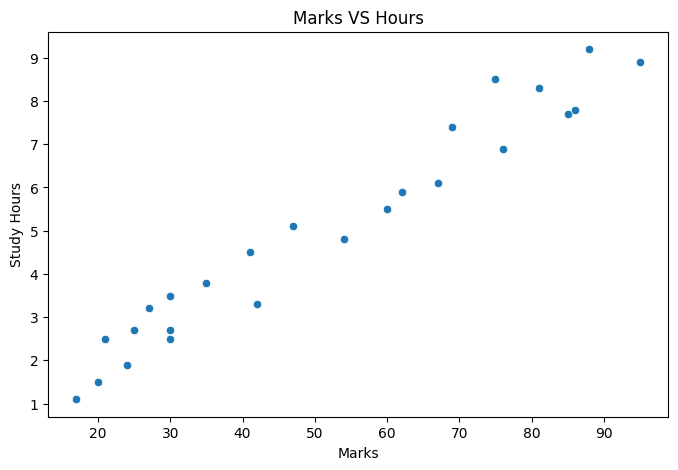

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Marks',
    y='Hours'
)

plt.title("Marks VS Hours")
plt.xlabel("Marks")
plt.ylabel("Study Hours")

plt.show()

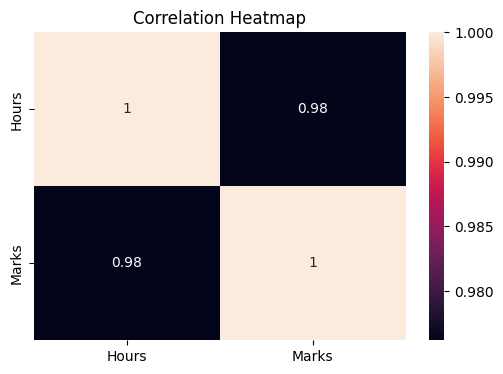

In [22]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
df['Hours'].mean()

5.012

In [25]:
df['Marks'].mean()

51.48

In [26]:
df['Marks'].max()

95

In [27]:
df['Marks'].min()

17

In [28]:
df.loc[df['Hours'].idxmax()]

Hours     9.2
Marks    88.0
Name: 6, dtype: float64

In [29]:
X=df[['Hours']]
y=df['Marks']

In [31]:
print(X.head())


   Hours
0    2.5
1    5.1
2    3.2
3    8.5
4    3.5


In [32]:
print(y.head())

0    21
1    47
2    27
3    75
4    30
Name: Marks, dtype: int64


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test=train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

In [36]:
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)

print("y_train: ",y_train.shape)
print("y_test: ",y_test.shape)


X_train:  (20, 1)
X_test:  (5, 1)
y_train:  (20,)
y_test:  (5,)


In [40]:
print(X_train.head())

    Hours
9     2.7
13    3.3
1     5.1
22    3.8
5     1.5


In [39]:
print(y_train.head())

9     25
13    42
1     47
22    35
5     20
Name: Marks, dtype: int64


In [44]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

print("slope:",model.coef_)
print("intercept:",model.intercept_)


slope: [9.68207815]
intercept: 2.826892353899737


In [ ]:
prediction=model.predict([[7]])
print("predictions for 7 hours :",prediction)

predictions for 7 hours : [70.60143944]


c:\Users\jabee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
hours=[[2],[5],[8]]
predictions=model.predict(hours)
print(predictions)

[22.19104866 51.23728313 80.28351759]


c:\Users\jabee\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [56]:
y_pred=model.predict(X_test)


In [59]:
comparison=pd.DataFrame({
    "Actual" : y_test,
    "predicted" : y_pred
})

print(comparison)

    Actual  predicted
8       81  83.188141
16      30  27.032088
0       21  27.032088
23      76  69.633232
11      62  59.951153


In [60]:
from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_test,y_pred)

print("MAE: ",mae)

MAE:  3.9207511902099244


In [61]:
from sklearn.metrics import r2_score

r2score=r2_score(y_test,y_pred)

print("R2_score: ",r2score)

R2_score:  0.9678055545167994


In [62]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 4.352380006653288


In [64]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2score)

MAE : 3.9207511902099244
RMSE: 4.352380006653288
R²  : 0.9678055545167994


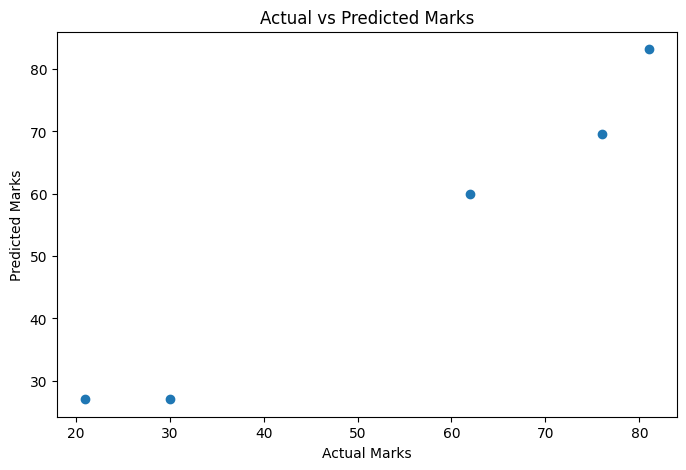

In [65]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

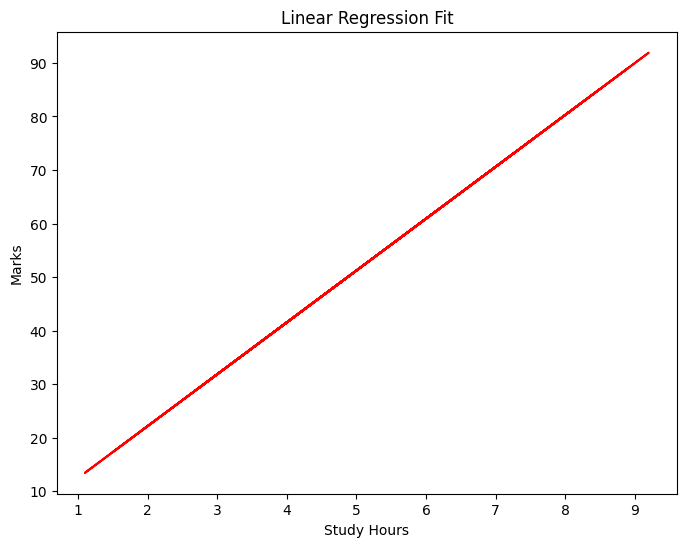

In [66]:
plt.figure(figsize=(8,6))

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression Fit")

plt.show()